# Metodologia Box Jenkins en ARMA

1. Estacionariedad → verificar (ADF) y transformar si hace falta (diferenciación, log...)
2. ACF/PACF → identificar p y q
3. Estimar el modelo con esos órdenes
3. Diagnosticar los residuos (Ljung-Box, ACF de residuos)

El siguiente codigo realiza los primeros 2 pasos de Box-Jenkins
+ Paso 1 Verificar Estacionariedad e 
+ Paso 2 Indetificar p y q mediante las funciones ACF y PACF

La serie es estacionaria
Diferenciaciones = 0, p-valor = 0.0000


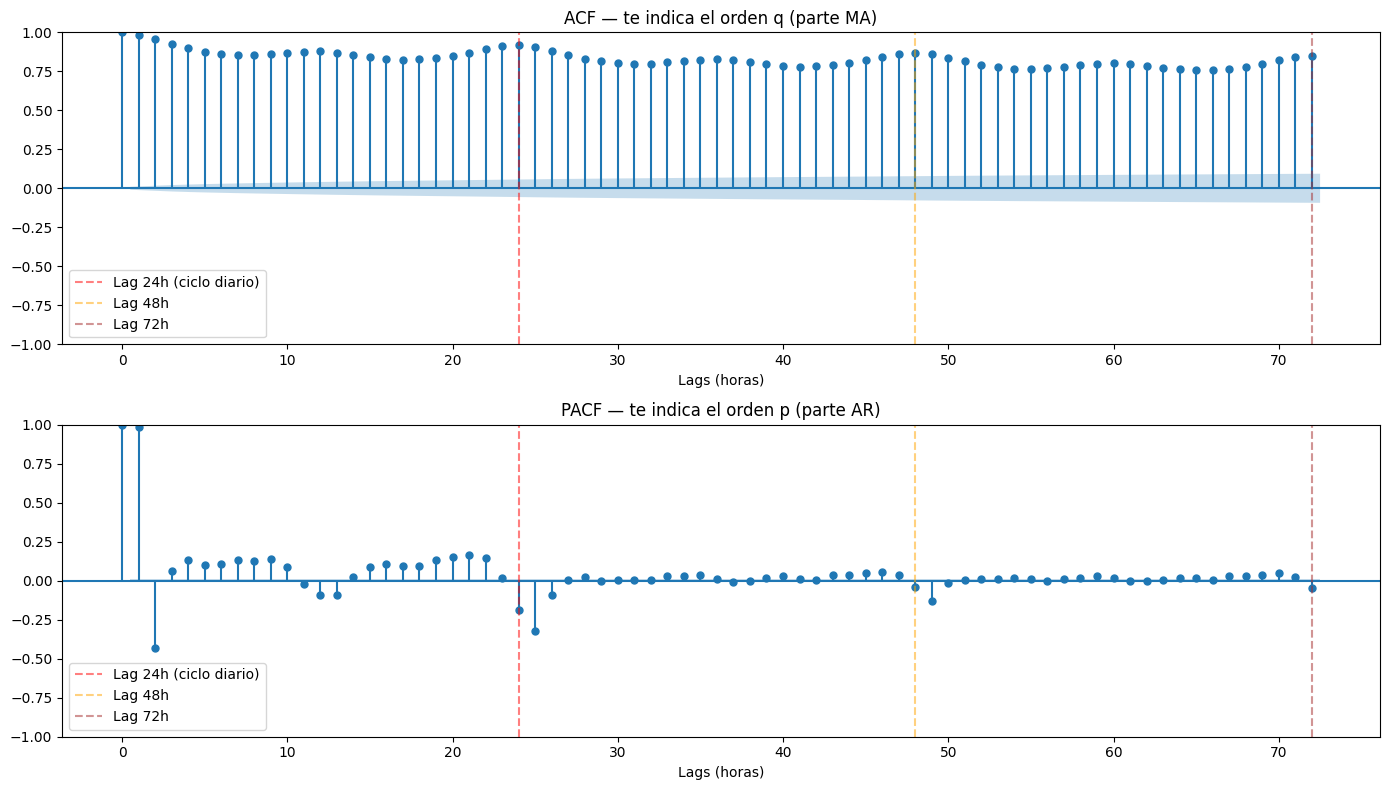

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ==============================
# 1. Cargar y preparar la serie (igual que antes)
# ==============================
df = pd.read_csv('limpiezaPrecio3_Omie2020_2024.csv', sep=";")
df['datetime'] = pd.to_datetime(df['datetime'])
#ordenar por fecha por si acaso
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True) 

serie = df['price'].replace([np.inf, -np.inf], np.nan).dropna()
serie = serie.asfreq('h')

# ==============================
# 2. Verificar estacionariedad
# ==============================
''' test = adfuller(serie)

#test[0] es el estadístico ADF (cuanto mas negativo más estacionaria es la serie)
#test[1] es el p-valor (si es menor a 0.05, rechazamos la hipótesis nula de no estacionariedad)

print(f'Estadístico ADF: {test[0]:.4f}')
print(f'p-valor:         {test[1]:.4f}')

if test[1] <= 0.05:
    print("Serie estacionaria -> podemos aplicar ARMA directamente")
    serie_modelo = serie
else:
    print("No estacionaria -> diferenciamos una vez")

    serie_modelo = serie.diff().dropna()
    # Verificar de nuevo
    res2 = adfuller(serie_modelo)
    print(f'ADF tras diferenciar: {res2[0]:.4f}, p-valor: {res2[1]:.4f}') '''


def hacer_estacionaria(serie, max_diff=5, alpha=0.05):
    """
    Aplica el test ADF y hasta max_diff diferenciaciones sucesivas hasta que la serie sea estacionaria
    
    Parametros:
    - serie: Serie temporal
    - max_diff: numero maximo de diferenciaciones a intentar (por defecto 5)
    - alpha: nivel de significancia (por defecto 0.05 = 5%)
    
    Retorna:
    - serie_transformada: Serie ya estacionaria (diferenciada n veces)
    - n_diff: total de diferenciaciones aplicadas
    - p_valor_final: p-valor del ultimo test ADF
    """
    # Copia para no modificar la original
    serie_actual = serie.copy()
    n_diff = 0
    
    #mientras no sea estacionaria y no superemos el máximo
    while n_diff <= max_diff:
        # Realizar test ADF
        resultado = adfuller(serie_actual.dropna())  # dropna por si hay NaN tras diff
        p_valor = resultado[1]
        
        # Mostrar informacion en cada paso
        #print(f"Diferenciaciones = {n_diff} -> p-valor = {p_valor:.4f}")
        
        # Si es estacionaria, salimos del bucle
        if p_valor <= alpha:
            print("La serie es estacionaria")
            break
        else:
            # Si no es estacionaria, aplicamos una diferenciacion 
            if n_diff < max_diff:
                print(f"No estacionaria. Aplicando diferenciacion {n_diff+1}...")
                # La diff consiste en restar el valor anterior al actual,
                # por lo que se pierde el primer valor (pasa a ser NaN), por eso dropna()
                # despues de cada diff
                serie_actual = serie_actual.diff().dropna()
                n_diff += 1
            else:
                print("Se llego al maximo de diferenciaciones sin lograr estacionariedad.")
                break
    
    return serie_actual, n_diff, p_valor

serie_modelo, n_diff, p_valor_final = hacer_estacionaria(serie)
print(f"Diferenciaciones = {n_diff}, p-valor = {p_valor_final:.4f}")


# ==============================
# 3. ACF y PACF para identificar p y q
# ==============================
# Usamos 72 lags (3 días) para ver los patrones diarios
# También se puede probar con lags=168 (ciclo semanal)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(serie_modelo, lags=72, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF — te indica el orden q (parte MA)')
axes[0].set_xlabel('Lags (horas)')
axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.5, label='Lag 24h (ciclo diario)')
axes[0].axvline(x=48, color='orange', linestyle='--', alpha=0.5, label='Lag 48h')
axes[0].axvline(x=72, color='brown', linestyle='--', alpha=0.5, label='Lag 72h')
axes[0].legend()

plot_pacf(serie_modelo, lags=72, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF — te indica el orden p (parte AR)')
axes[1].set_xlabel('Lags (horas)')
axes[1].axvline(x=24, color='red', linestyle='--', alpha=0.5, label='Lag 24h (ciclo diario)')
axes[1].axvline(x=48, color='orange', linestyle='--', alpha=0.5, label='Lag 48h')
axes[1].axvline(x=72, color='brown', linestyle='--', alpha=0.5, label='Lag 72h')
axes[1].legend()

plt.tight_layout()
plt.savefig('box_jenkins_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## Como interpretar resultados, :

1. Si PACF corta bruscamente en un lag p, mientras que ACF decae gradualmente -> Modelo AR(p)
2. Si ACF corta bruscamente en un lag q, minetras que PACF decae gradualmente -> Modelo MA(q)
3. Ambas decaen gradualmente -> Modelo ARMA(p,q) mixto
4. Picos significativos en ambos en lag 24, 48... ->  Hay estacionalidad -> SARIMA (p,d,q)(P,D,Q,24)

### Resultados del precio:

* ACF (arriba): Todos los lags hasta 72 son altamente significativos (~0.8) y hay picos cada 24 horas (lag 24, 48, 72...). Esto es una decaimiento lentísimo con patrón estacional periódico cada 24h.
* PACF (abajo): Corte brusco después del lag 1 (con un pico negativo fuerte en lag 2), luego valores pequeños pero con picos negativos en lag 24, 48 y 72

Claramente estamos en el primer caso de los anteriormente vistos, aunque PACF decae lentamente despues de cortar en el lag 2
Así que el modelo seria ARMA(2,1). Porque:
p = 2 (PACF corta tras lag 2)
q = 1 (la ACF decae gradualmente -> componente MA pequeño)

Pero , ARMA con estos datos va a seguir siendo mediocre porque ignora completamente el ciclo de 24h. Documentarlo así: "ARMA no captura la estacionalidad, como confirman las ACF/PACF, lo que justifica el uso de SARIMA"